In [1]:
!pip install -q xgboost shap imbalanced-learn mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 41.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 39.9 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 27.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 2.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 5.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 21.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.0/216.0 kB 4.3 MB/s eta 0:00:00:00:01

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support, roc_auc_score
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [4]:
df = pd.read_csv('/kaggle/input/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020/ai4i2020.csv')
print(df.shape)
df.head()

(10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [6]:
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('[', '').str.replace(']', '')
print(df.columns.tolist())

['UDI', 'Product_ID', 'Type', 'Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Machine_failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [ ]:
print("Machine failure distribution:")
print(df['Machine_failure'].value_counts())
print(f"\nFailure rate: {df['Machine_failure'].mean()*100:.2f}%")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df['Machine_failure'].value_counts().plot(kind='bar', ax=ax[0], color=['steelblue', 'crimson'])
ax[0].set_title('Machine Failure (0 = No, 1 = Yes)')

failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df[failure_types].sum().plot(kind='bar', ax=ax[1], color='darkorange')
ax[1].set_title('Failure Type Counts (among all failures)')
plt.tight_layout()
plt.show()

Machine failure distribution:
Machine_failure
0    9661
1     339
Name: count, dtype: int64

Failure rate: 3.39%


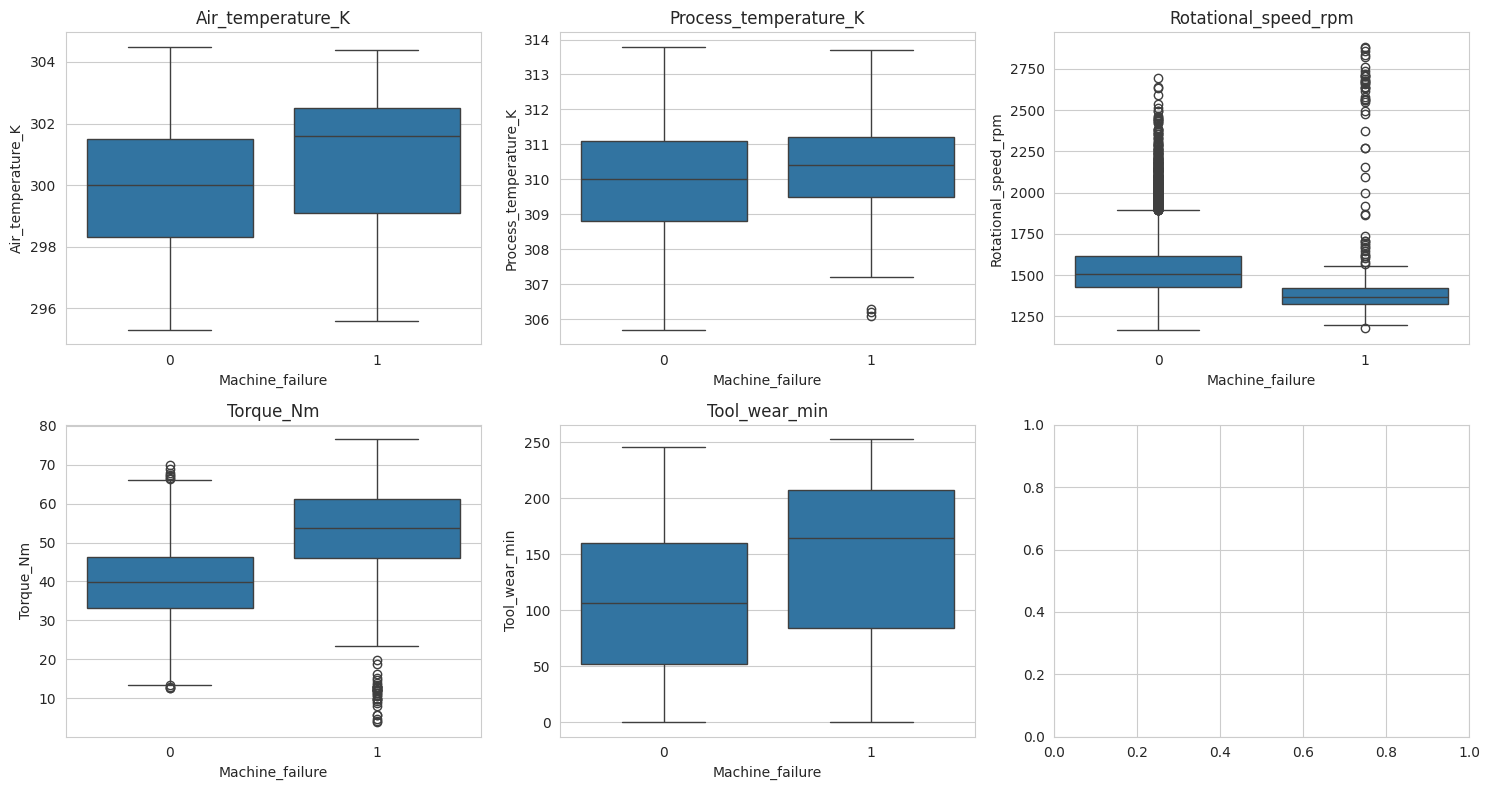

In [8]:
numeric_features = ['Air_temperature_K', 'Process_temperature_K',
                     'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    sns.boxplot(data=df, x='Machine_failure', y=col, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

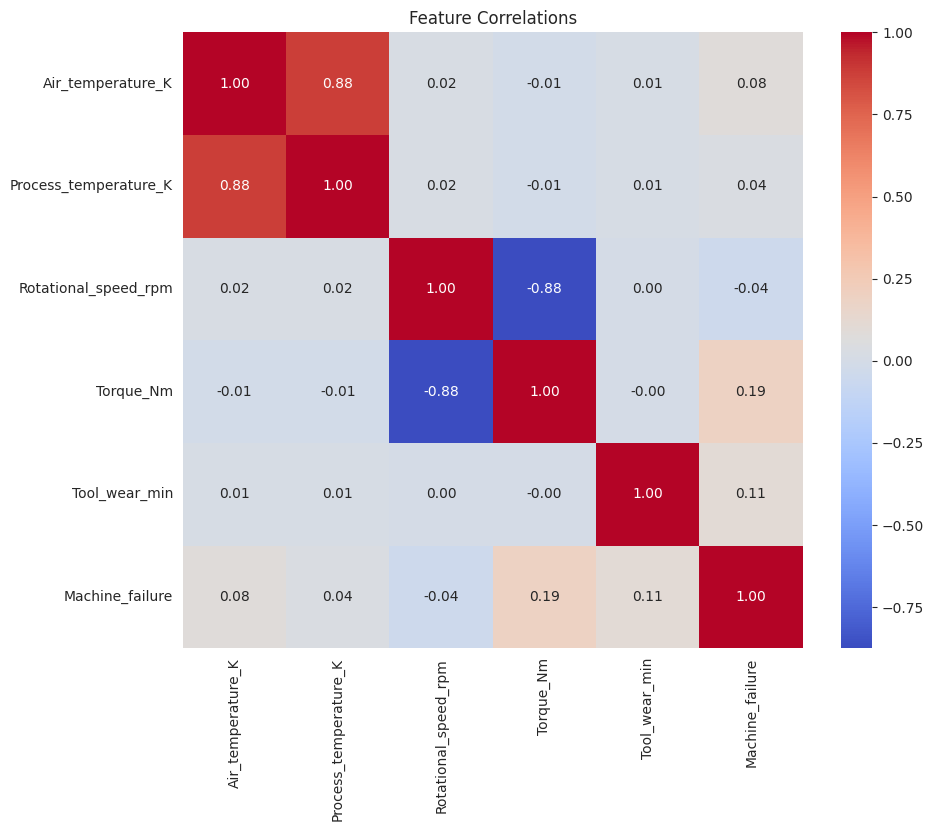

In [9]:
plt.figure(figsize=(10, 8))
corr_cols = numeric_features + ['Machine_failure']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlations')
plt.show()

In [11]:
# Encode product quality variant (Type: L/M/H)
le = LabelEncoder()
df['Type_encoded'] = le.fit_transform(df['Type'])

feature_cols = ['Type_encoded'] + numeric_features
X = df[feature_cols]
y = df['Machine_failure']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train failure rate: {y_train.mean()*100:.2f}%, Test failure rate: {y_test.mean()*100:.2f}%")

Train shape: (8000, 6), Test shape: (2000, 6)
Train failure rate: 3.39%, Test failure rate: 3.40%


=== SVM (baseline) ===
              precision    recall  f1-score   support

  No Failure       0.97      1.00      0.99      1932
     Failure       0.88      0.21      0.33        68

    accuracy                           0.97      2000
   macro avg       0.92      0.60      0.66      2000
weighted avg       0.97      0.97      0.96      2000



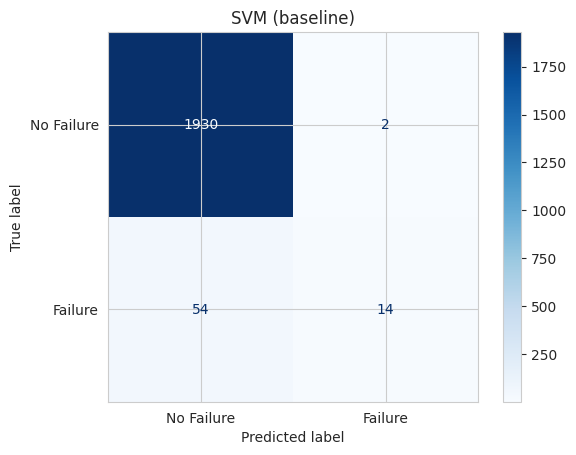

=== Decision Tree (baseline) ===
              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1932
     Failure       0.68      0.75      0.71        68

    accuracy                           0.98      2000
   macro avg       0.84      0.87      0.85      2000
weighted avg       0.98      0.98      0.98      2000



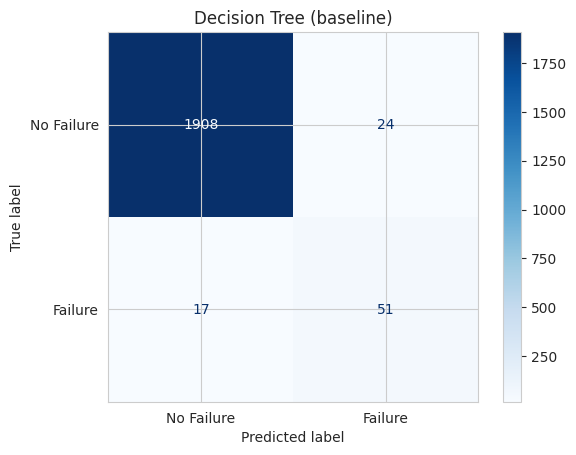

=== Logistic Regression (baseline) ===
              precision    recall  f1-score   support

  No Failure       0.97      1.00      0.98      1932
     Failure       0.67      0.12      0.20        68

    accuracy                           0.97      2000
   macro avg       0.82      0.56      0.59      2000
weighted avg       0.96      0.97      0.96      2000



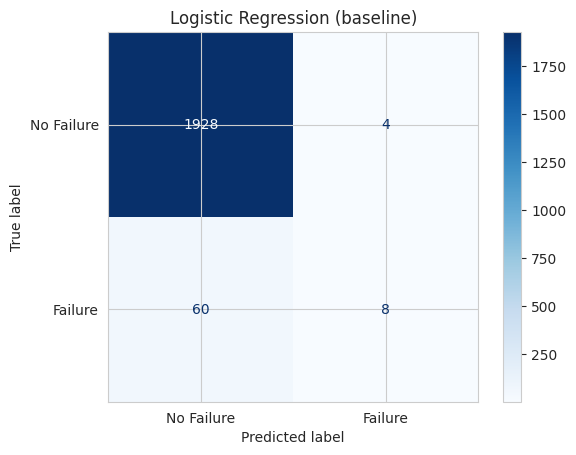

In [12]:
def evaluate_model(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    print(f"=== {name} ===")
    print(classification_report(y_te, y_pred, target_names=['No Failure', 'Failure']))
    cm = confusion_matrix(y_te, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Failure', 'Failure']).plot(cmap='Blues')
    plt.title(name)
    plt.show()
    return y_pred

baseline_results = {}

# SVM baseline
svm_baseline = SVC(kernel='rbf', random_state=42)
svm_baseline.fit(X_train_scaled, y_train)
baseline_results['SVM'] = evaluate_model('SVM (baseline)', svm_baseline, X_test_scaled, y_test)

# Decision Tree baseline
dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(X_train, y_train)
baseline_results['Decision Tree'] = evaluate_model('Decision Tree (baseline)', dt_baseline, X_test, y_test)

# Logistic Regression baseline
lr_baseline = LogisticRegression(random_state=42, max_iter=1000)
lr_baseline.fit(X_train_scaled, y_train)
baseline_results['Logistic Regression'] = evaluate_model('Logistic Regression (baseline)', lr_baseline, X_test_scaled, y_test)

In [13]:
results_summary = []

def get_metrics(name, y_true, y_pred, y_proba=None):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', pos_label=1
    )
    auc = roc_auc_score(y_true, y_proba) if y_proba is not None else None
    results_summary.append({
        'Model': name, 'Precision': precision, 'Recall': recall,
        'F1': f1, 'ROC-AUC': auc
    })
    print(f"{name}: Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}, ROC-AUC={auc}")

# Log baseline metrics first, for comparison
get_metrics('SVM (baseline)', y_test, baseline_results['SVM'])
get_metrics('Decision Tree (baseline)', y_test, baseline_results['Decision Tree'])
get_metrics('Logistic Regression (baseline)', y_test, baseline_results['Logistic Regression'])

SVM (baseline): Precision=0.875, Recall=0.206, F1=0.333, ROC-AUC=None
Decision Tree (baseline): Precision=0.680, Recall=0.750, F1=0.713, ROC-AUC=None
Logistic Regression (baseline): Precision=0.667, Recall=0.118, F1=0.200, ROC-AUC=None


=== SVM (class-weighted) ===
              precision    recall  f1-score   support

  No Failure       1.00      0.92      0.96      1932
     Failure       0.28      0.91      0.43        68

    accuracy                           0.92      2000
   macro avg       0.64      0.92      0.69      2000
weighted avg       0.97      0.92      0.94      2000



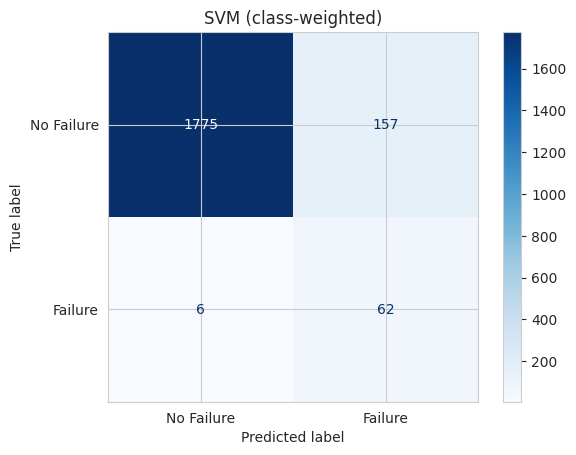

SVM (class-weighted): Precision=0.283, Recall=0.912, F1=0.432, ROC-AUC=0.9643694434295458


In [14]:
# SVM with class_weight='balanced'
svm_weighted = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
svm_weighted.fit(X_train_scaled, y_train)
y_pred_svm_w = evaluate_model('SVM (class-weighted)', svm_weighted, X_test_scaled, y_test)
get_metrics('SVM (class-weighted)', y_test, y_pred_svm_w, svm_weighted.predict_proba(X_test_scaled)[:, 1])

=== Decision Tree (class-weighted) ===
              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1932
     Failure       0.71      0.60      0.65        68

    accuracy                           0.98      2000
   macro avg       0.85      0.80      0.82      2000
weighted avg       0.98      0.98      0.98      2000



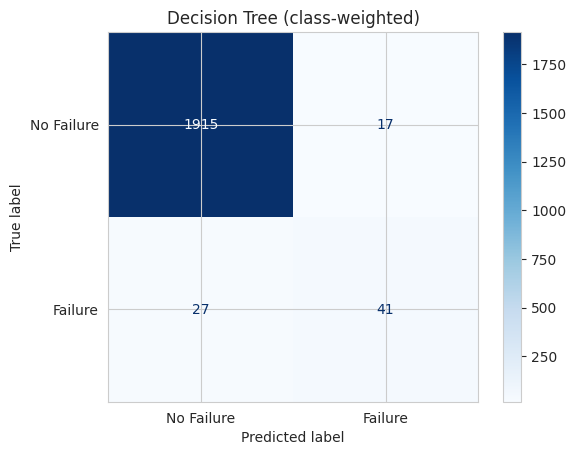

Decision Tree (class-weighted): Precision=0.707, Recall=0.603, F1=0.651, ROC-AUC=0.7970710023139691


In [16]:
# Decision Tree with class_weight='balanced'
dt_weighted = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_weighted.fit(X_train, y_train)
y_pred_dt_w = evaluate_model('Decision Tree (class-weighted)', dt_weighted, X_test, y_test)
get_metrics('Decision Tree (class-weighted)', y_test, y_pred_dt_w, dt_weighted.predict_proba(X_test)[:, 1])

In [17]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE: {pd.Series(y_train_smote).value_counts().to_dict()}")

Before SMOTE: {0: 7729, 1: 271}
After SMOTE: {0: 7729, 1: 7729}


=== SVM (SMOTE) ===
              precision    recall  f1-score   support

  No Failure       1.00      0.92      0.96      1932
     Failure       0.29      0.90      0.43        68

    accuracy                           0.92      2000
   macro avg       0.64      0.91      0.69      2000
weighted avg       0.97      0.92      0.94      2000



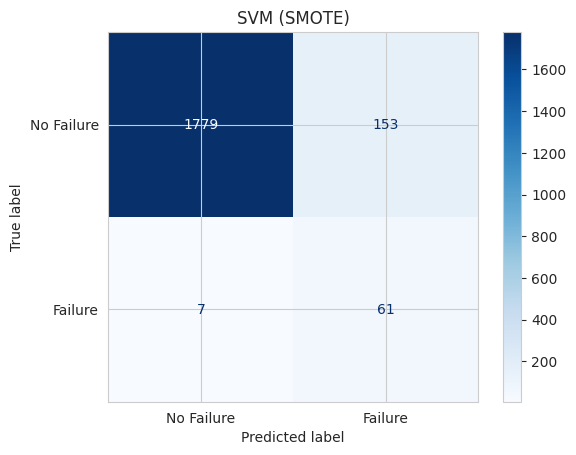

SVM (SMOTE): Precision=0.285, Recall=0.897, F1=0.433, ROC-AUC=0.9641639264401413


In [18]:
svm_smote = SVC(kernel='rbf', probability=True, random_state=42)
svm_smote.fit(X_train_smote, y_train_smote)
y_pred_svm_smote = evaluate_model('SVM (SMOTE)', svm_smote, X_test_scaled, y_test)
get_metrics('SVM (SMOTE)', y_test, y_pred_svm_smote, svm_smote.predict_proba(X_test_scaled)[:, 1])

=== Decision Tree (SMOTE) ===
              precision    recall  f1-score   support

  No Failure       0.99      0.95      0.97      1932
     Failure       0.34      0.68      0.45        68

    accuracy                           0.94      2000
   macro avg       0.66      0.82      0.71      2000
weighted avg       0.97      0.94      0.95      2000



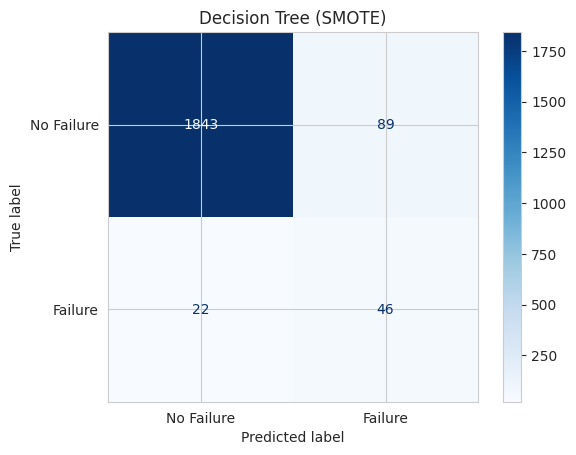

Decision Tree (SMOTE): Precision=0.341, Recall=0.676, F1=0.453, ROC-AUC=0.8152021678236513


In [20]:
# Decision tree needs unscaled SMOTE data - regenerate on the unscaled training set
X_train_smote_raw, y_train_smote_raw = smote.fit_resample(X_train, y_train)

dt_smote = DecisionTreeClassifier(random_state=42)
dt_smote.fit(X_train_smote_raw, y_train_smote_raw)
y_pred_dt_smote = evaluate_model('Decision Tree (SMOTE)', dt_smote, X_test, y_test)
get_metrics('Decision Tree (SMOTE)', y_test, y_pred_dt_smote, dt_smote.predict_proba(X_test)[:, 1])

=== Random Forest (class-weighted) ===
              precision    recall  f1-score   support

  No Failure       0.98      1.00      0.99      1932
     Failure       0.88      0.53      0.66        68

    accuracy                           0.98      2000
   macro avg       0.93      0.76      0.83      2000
weighted avg       0.98      0.98      0.98      2000



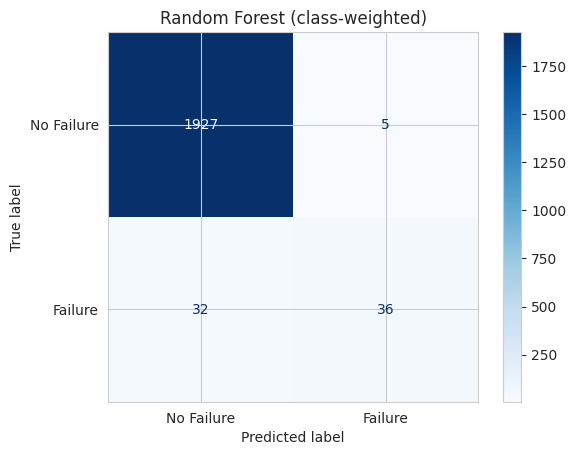

Random Forest (class-weighted): Precision=0.878, Recall=0.529, F1=0.661, ROC-AUC=0.9669498234076239


In [21]:
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = evaluate_model('Random Forest (class-weighted)', rf, X_test, y_test)
get_metrics('Random Forest (class-weighted)', y_test, y_pred_rf, rf.predict_proba(X_test)[:, 1])

scale_pos_weight: 28.52
=== XGBoost (weighted) ===
              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1932
     Failure       0.75      0.76      0.76        68

    accuracy                           0.98      2000
   macro avg       0.87      0.88      0.88      2000
weighted avg       0.98      0.98      0.98      2000



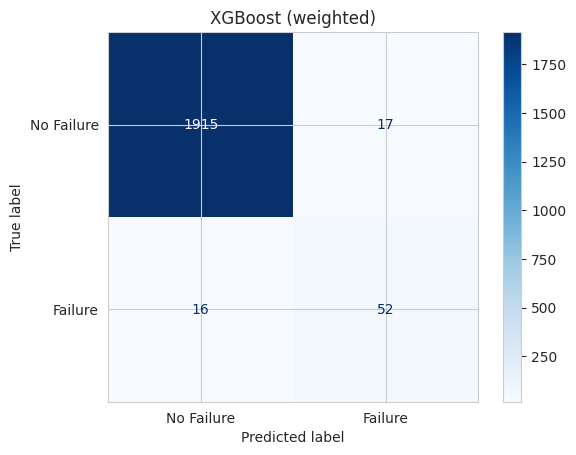

XGBoost (weighted): Precision=0.754, Recall=0.765, F1=0.759, ROC-AUC=0.9641410912190963


In [22]:
# XGBoost uses scale_pos_weight instead of class_weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=200, scale_pos_weight=scale_pos_weight,
    random_state=42, eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = evaluate_model('XGBoost (weighted)', xgb_model, X_test, y_test)
get_metrics('XGBoost (weighted)', y_test, y_pred_xgb, xgb_model.predict_proba(X_test)[:, 1])

In [23]:
results_df = pd.DataFrame(results_summary).sort_values('F1', ascending=False)
results_df.style.background_gradient(subset=['Precision', 'Recall', 'F1', 'ROC-AUC'], cmap='Greens')

,Model,Precision,Recall,F1,ROC-AUC
10,XGBoost (weighted),0.753623,0.764706,0.759124,0.964141
1,Decision Tree (baseline),0.680000,0.750000,0.713287,nan
9,Random Forest (class-weighted),0.878049,0.529412,0.660550,0.966950
4,Decision Tree (class-weighted),0.706897,0.602941,0.650794,0.797071
5,Decision Tree (class-weighted),0.706897,0.602941,0.650794,0.797071
8,Decision Tree (SMOTE),0.340741,0.676471,0.453202,0.815202
7,Decision Tree (SMOTE),0.340741,0.676471,0.453202,0.815202
6,SVM (SMOTE),0.285047,0.897059,0.432624,0.964164
3,SVM (class-weighted),0.283105,0.911765,0.432056,0.964369
0,SVM (baseline),0.875000,0.205882,0.333333,nan


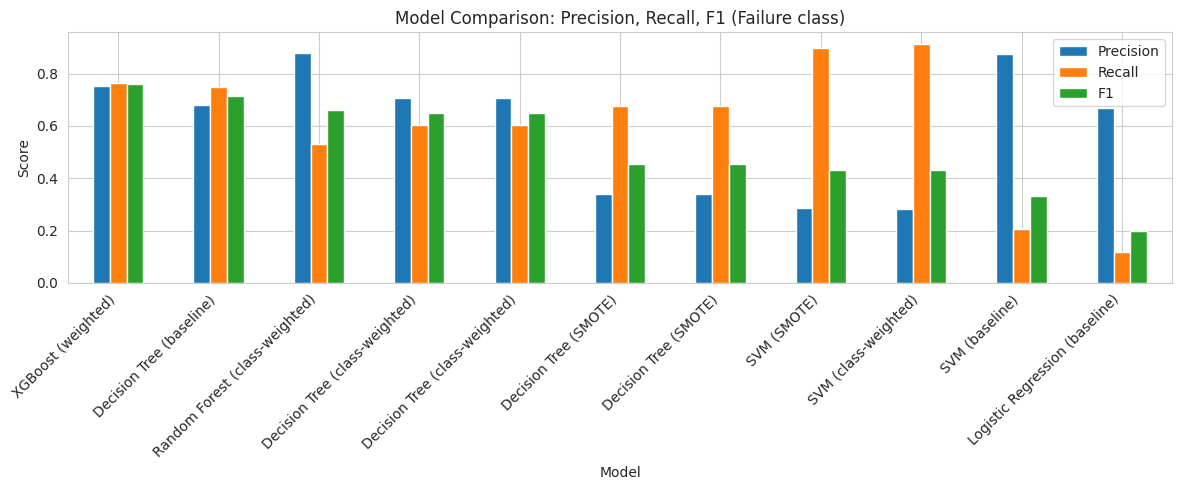

In [24]:
results_df.plot(x='Model', y=['Precision', 'Recall', 'F1'], kind='bar', figsize=(12, 5))
plt.title('Model Comparison: Precision, Recall, F1 (Failure class)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

In [25]:
best_model = xgb_model
best_model_name = "XGBoost (weighted)"
X_test_for_shap = X_test  # use X_test_scaled instead if your winner needed scaled input 

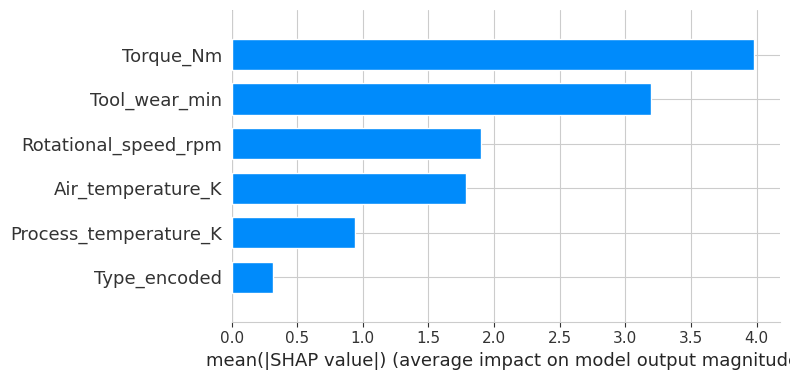

In [26]:
# TreeExplainer is fast and exact for tree-based models (XGBoost, Random Forest, Decision Tree).
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_for_shap)

# Global feature importance - which features matter most overall
shap.summary_plot(shap_values, X_test_for_shap, feature_names=feature_cols, plot_type='bar')

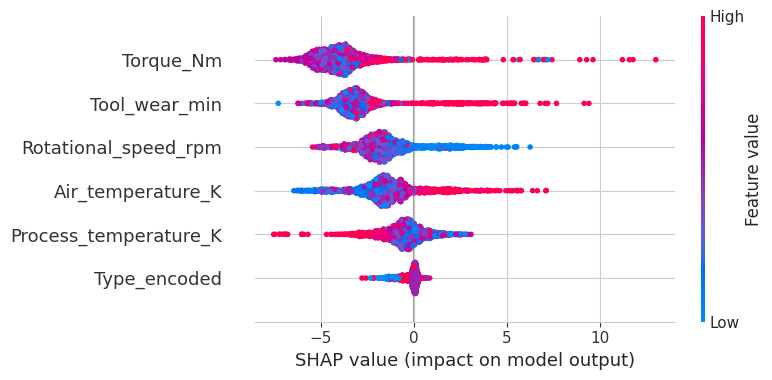

In [27]:
shap.summary_plot(shap_values, X_test_for_shap, feature_names=feature_cols)

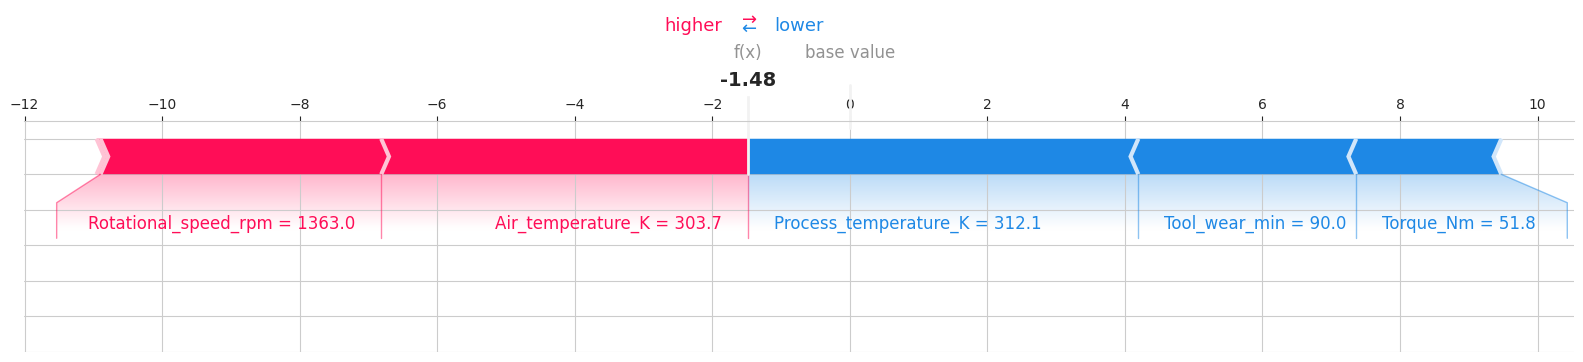

In [28]:
# Explain one individual prediction - pick a true-failure case the model correctly caught
failure_indices = np.where(y_test.values == 1)[0]
sample_idx = failure_indices[0]

shap.force_plot(
    explainer.expected_value, shap_values[sample_idx],
    X_test_for_shap.iloc[sample_idx] if hasattr(X_test_for_shap, 'iloc') else X_test_for_shap[sample_idx],
    feature_names=feature_cols, matplotlib=True
)

In [29]:
import joblib
import os

os.makedirs('/kaggle/working/model_artifacts', exist_ok=True)

joblib.dump(best_model, '/kaggle/working/model_artifacts/model.pkl')
joblib.dump(scaler, '/kaggle/working/model_artifacts/scaler.pkl')
joblib.dump(le, '/kaggle/working/model_artifacts/label_encoder.pkl')

# Save the exact feature order the model expects - critical for the API step
import json
with open('/kaggle/working/model_artifacts/feature_config.json', 'w') as f:
    json.dump({
        'feature_cols': feature_cols,
        'needs_scaling': best_model_name.startswith('SVM'),  # adjust based on your actual winner
        'model_name': best_model_name
    }, f, indent=2)

print("Saved artifacts:")
print(os.listdir('/kaggle/working/model_artifacts'))

Saved artifacts:
['model.pkl', 'feature_config.json', 'scaler.pkl', 'label_encoder.pkl']


In [30]:
results_df.to_csv('/kaggle/working/model_comparison_results.csv', index=False)
results_df

,Model,Precision,Recall,F1,ROC-AUC
10,XGBoost (weighted),0.753623,0.764706,0.759124,0.964141
1,Decision Tree (baseline),0.680000,0.750000,0.713287,NaN
9,Random Forest (class-weighted),0.878049,0.529412,0.660550,0.966950
4,Decision Tree (class-weighted),0.706897,0.602941,0.650794,0.797071
5,Decision Tree (class-weighted),0.706897,0.602941,0.650794,0.797071
8,Decision Tree (SMOTE),0.340741,0.676471,0.453202,0.815202
7,Decision Tree (SMOTE),0.340741,0.676471,0.453202,0.815202
6,SVM (SMOTE),0.285047,0.897059,0.432624,0.964164
3,SVM (class-weighted),0.283105,0.911765,0.432056,0.964369
0,SVM (baseline),0.875000,0.205882,0.333333,NaN
